## Code Testing Notebook

This notebook tests the various classes and functionalities of the psBQP (pseudo-spin Bogoliubov Quasiparticle) Keldysh implementation.

In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import sys

# Import our classes
from nambu_keldysh_class import NambuKeldyshTensor
from state_object_class import StateObject
from equilibrium_class import EquilibriumSolver
from usadel_keldysh_evolution import UsadelKeldyshEvolution

print("All imports successful!")

All imports successful!


In [2]:
def plot_nambu_components(nambu_tensor, time_grid, title="Nambu-Keldysh Tensor Components", 
                          vmin=None, vmax=None, cmap='RdBu_r', 
                          t_lim=None, tprime_lim=None):
    """
    Plot all 4 Pauli components of a NambuKeldyshTensor in a 4x2 grid.
    
    Args:
        nambu_tensor: NambuKeldyshTensor with shape (2, 2, Nt, Nt)
                     component[i, j] represents g(t_i, t'_j)
        time_grid: Array of time values corresponding to the tensor indices
        title: Overall title for the figure
        vmin, vmax: Optional colorbar limits (if None, auto-scale per component)
        cmap: Colormap to use (default 'RdBu_r' for diverging red-blue)
        t_lim: Optional tuple (t_min, t_max) to zoom into specific t range
        tprime_lim: Optional tuple (tprime_min, tprime_max) to zoom into specific t' range
    
    Layout:
        Top row: Real parts of [I, X, Y, Z] components
        Bottom row: Imaginary parts of [I, X, Y, Z] components
        
    Convention:
        After transpose, x-axis = t (first index), y-axis = t' (second index)
        Smallest times in top-left corner
    """
    pauli_labels = ['I (Identity)', 'X (σ_x)', 'Y (σ_y)', 'Z (σ_z)']
    
    # Create figure with 4 columns (Pauli components) x 2 rows (real/imag)
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    
    # Time extent for imshow (smallest times in top-left corner)
    # After transpose: x-axis is t, y-axis is t'
    t_min, t_max = time_grid[0], time_grid[-1]
    extent = [t_min, t_max, t_max, t_min]  # [left, right, bottom, top] with origin='upper'
    
    # Extract each Pauli component and plot
    for pauli_idx in range(4):
        # Extract Pauli component using trace (divide by 2 for normalization)
        component = nambu_tensor.trace(pauli_index=pauli_idx) / 2
        
        # Transpose: component[i,j] -> component.T[j,i]
        # So x-axis (columns) = i = t, y-axis (rows) = j = t'
        
        # Real part (top row)
        ax_real = axes[0, pauli_idx]
        im_real = ax_real.imshow(np.real(component), aspect='auto', origin='upper',
                                 extent=extent, cmap=cmap, vmin=vmin, vmax=vmax)
        ax_real.set_title(f"{pauli_labels[pauli_idx]} - Real", fontsize=10)
        ax_real.set_ylabel("t", fontsize=9)
        if pauli_idx == 0:
            ax_real.set_ylabel("t", fontsize=11, fontweight='bold')
        
        # Apply axis limits if specified
        if t_lim is not None:
            ax_real.set_xlim(t_lim)
        if tprime_lim is not None:
            ax_real.set_ylim(tprime_lim[1], tprime_lim[0])  # Reversed for origin='upper'
        
        plt.colorbar(im_real, ax=ax_real, fraction=0.046, pad=0.04)
        
        # Imaginary part (bottom row)
        ax_imag = axes[1, pauli_idx]
        im_imag = ax_imag.imshow(np.imag(component), aspect='auto', origin='upper',
                                 extent=extent, cmap=cmap, vmin=vmin, vmax=vmax)
        ax_imag.set_title(f"{pauli_labels[pauli_idx]} - Imag", fontsize=10)
        ax_imag.set_xlabel("t'", fontsize=11, fontweight='bold')
        ax_imag.set_ylabel("t", fontsize=9)
        if pauli_idx == 0:
            ax_imag.set_ylabel("t", fontsize=11, fontweight='bold')
        
        # Apply axis limits if specified
        if t_lim is not None:
            ax_imag.set_xlim(t_lim)
        if tprime_lim is not None:
            ax_imag.set_ylim(tprime_lim[1], tprime_lim[0])  # Reversed for origin='upper'
        
        plt.colorbar(im_imag, ax=ax_imag, fraction=0.046, pad=0.04)
    
    # Overall title
    fig.suptitle(title, fontsize=14, fontweight='bold', y=0.995)
    
    plt.tight_layout()
    plt.show()

print("Plotting function defined: plot_nambu_components()")

Plotting function defined: plot_nambu_components()


### Example: Save and Load State

Uncomment the code below to test saving and loading:

In [3]:
def save_state(state, filename):
    """
    Save a StateObject to a file using pickle.
    
    Args:
        state: StateObject to save
        filename: Path to save file (will add .pkl extension if not present)
    
    Returns:
        str: Full path to saved file
    """
    import pickle
    import os
    
    # Add .pkl extension if not present
    if not filename.endswith('.pkl'):
        filename = filename + '.pkl'
    
    # Save using pickle
    with open(filename, 'wb') as f:
        pickle.dump(state, f)
    
    # Get absolute path for confirmation
    abs_path = os.path.abspath(filename)
    print(f"State saved to: {abs_path}")
    print(f"  g^R shape: {state.gr.data.shape}")
    print(f"  g^K shape: {state.gk.data.shape}")
    
    return abs_path


def load_state(filename):
    """
    Load a StateObject from a file.
    
    Args:
        filename: Path to saved state file
    
    Returns:
        StateObject: Loaded state object
    """
    import pickle
    import os
    
    # Add .pkl extension if not present
    if not filename.endswith('.pkl'):
        filename = filename + '.pkl'
    
    # Check if file exists
    if not os.path.exists(filename):
        raise FileNotFoundError(f"File not found: {filename}")
    
    # Load using pickle
    with open(filename, 'rb') as f:
        state = pickle.load(f)
    
    print(f"State loaded from: {os.path.abspath(filename)}")
    print(f"  g^R shape: {state.gr.data.shape}")
    print(f"  g^K shape: {state.gk.data.shape}")
    
    # Extract gap if available
    try:
        gap_history = state.get_gap_history()
        print(f"  Gap at final time: {gap_history[-1]:.4f}")
    except:
        print("  Could not extract gap history")
    
    return state


print("State I/O functions defined: save_state(), load_state()")

State I/O functions defined: save_state(), load_state()


In [4]:
--stop-- 

SyntaxError: invalid syntax (1955652615.py, line 1)

---
## 1. NambuKeldyshTensor Class Tests <a name="nambu-keldysh-tensor"></a>

Test basic operations of the NambuKeldyshTensor class.

### 1.1 Creation and Initialization

In [ ]:
# Test creating NambuKeldyshTensor with different Pauli indices
print("Testing NambuKeldyshTensor creation:")

# Create simple test data
test_data = np.array([1.0, 1.0 + 1j, 1.0j], dtype=complex)

a_data = np.array([[1,2,3],[4,5,6],[7,8,9]])
b_data = a_data.T
# Create tensors with different Pauli indices
Amatrix = NambuKeldyshTensor(a_data, pauli_channel=1)
v1 = NambuKeldyshTensor(test_data, pauli_channel=3)
v2 = NambuKeldyshTensor(test_data.T, pauli_channel=3)
tau_3 = NambuKeldyshTensor(1, pauli_channel=3)
scalar = 1j

print('Amatrix')
print(Amatrix)
print('v1')
print(v1)
print('tau_3')
print(tau_3)
print('scalar')
print(scalar)



Testing NambuKeldyshTensor creation:
Amatrix
Id Trace: [[0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]] 
 X Trace: [[ 2.+0.j  4.+0.j  6.+0.j]
 [ 8.+0.j 10.+0.j 12.+0.j]
 [14.+0.j 16.+0.j 18.+0.j]] 
 Y Trace: [[0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]] 
 Z Trace: [[0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]] 

v1
Id Trace: [0.+0.j 0.+0.j 0.+0.j] 
 X Trace: [0.+0.j 0.+0.j 0.+0.j] 
 Y Trace: [0.+0.j 0.+0.j 0.+0.j] 
 Z Trace: [2.+0.j 2.+2.j 0.+2.j] 

tau_3
Id Trace: 0j 
 X Trace: 0j 
 Y Trace: 0j 
 Z Trace: (2+0j) 

scalar
1j


### 1.2 Simple operations, addition, subtraction etc

In [ ]:
# Test addition and scalar multiplication
print('tau_3 + tau_3')
print(tau_3 + tau_3)
print('v1 + v1')
print(v1 + v1)
print('Amatrix + Amatrix')
print(Amatrix + Amatrix)


### 1.3 Mutliplication possiblities

In [ ]:
# Test addition and scalar multiplication

print('Same shape multiplication')
print('tau_3 * tau_3')
print(tau_3 * tau_3)
print('v1 * v1')
print(v1 * v1)
print('Amatrix * Amatrix')
print(Amatrix * Amatrix)

print('Scalar multiplication')
print('scalar * tau_3')
print(scalar * tau_3)
print('scalar * v1')
print(scalar * v1)
print('scalar * Amatrix')
print(scalar * Amatrix)
print('Different shape multiplication')

print('tau_3 * Amatrix')
print(tau_3 * Amatrix)
print('Amatrix * tau_3')
print(Amatrix * tau_3)
print('v1 * Amatrix')
print(v1 * Amatrix)
print('Amatrix * v1')
print(Amatrix * v1)


### 1.4 Matrix Multiplication (@)

In [ ]:
print('A conv A')
print(0* (Amatrix @ Amatrix))


### 1.5 Involution and related operations

In [ ]:
print('A transpose')
print(Amatrix.transpose())
print('A complete transpose')
print(Amatrix.complete_transpose())
print('A dagger')
print(Amatrix.conj().transpose())
print('A involution')
print(Amatrix.involution())

### 1.6 Test plotting function

In [ ]:
# Test the plotting function with the Amatrix we created earlier
# Create a simple time grid for the 3x3 test matrix
test_time_grid = np.linspace(-1, 0, 3)

print("Testing plot_nambu_components() with simple 3x3 matrix:")
plot_nambu_components(Amatrix, test_time_grid, 
                     title="Test: Simple 3x3 Amatrix (X-component only)")

### 1.7 Test update method

In [ ]:
Amatrix = NambuKeldyshTensor(a_data, pauli_channel=1)
print(v1)
print('Old A matrix')
print(Amatrix)
Amatrix.update_entries(v1 ,2*v2 * 0,tau_3 * 7)
print('New A matrix')
print(Amatrix)
Amatrix.update_entries(v1 ,2*v2 * 0,tau_3 * 7)
print('Newest A matrix')
print(Amatrix)

### Conclusion:

- Nambu class operations work as expected
- Other algebraic features work, including the update method

---
## 2. Equilibrium Generation Test <a name="equilibrium-generation"></a>

Test generating equilibrium initial state.

### 2.1 Create Evolution Object and Generate Initial State

### 2.1 Visualize Equilibrium Green's Functions with New Plotting Function

In [5]:
print("Testing equilibrium initial state generation:")
print()

# Define grid parameters
grid_parameters = {
    'time_sampling': 1501,
    'time_duration': 2* np.pi * 5,
    'eta': 0.2
}

# Define system parameters
system_parameters = {
    'critical_temperature': 1.0,
    'temperature': 0.3,
    'eta': 0.2

}

# Create evolution object
evolution = UsadelKeldyshEvolution(grid_parameters, system_parameters)
print(f"Evolution object created")
print(f"  Time grid: {evolution.ntpoints} points from {evolution.time_grid[0]:.2f} to {evolution.time_grid[-1]:.2f}")
print(f"  BCS coupling: {evolution._get_BCS_coupling():.4f}")
print()

# Generate initial equilibrium state
print("Generating initial equilibrium state...")
initial_state, greps, gkeps = evolution.generate_initial_state(Q=0.0)
print(f"Initial state generated")
print(f"  g^R shape: {initial_state.gr.data.shape}")
print(f"  g^K shape: {initial_state.gk.data.shape}")
print()

# Extract gap from initial state
gap_history = initial_state.get_gap_history()
print(f"Gap values:")
print(f"  Mean: {np.mean(np.abs(gap_history)):.4f}")
print(f"  Std: {np.std(np.abs(gap_history)):.4f}")
print(f"  First value: {gap_history[0]:.4f}")
print(f"  Last value: {gap_history[-1]:.4f}")

save_state((initial_state), 'initial_state_test.pkl')

Testing equilibrium initial state generation:

Evolution object created
  Time grid: 1501 points from -31.42 to 0.00
  BCS coupling: 1.2235

Generating initial equilibrium state...

Frequency Grid Information:
  Maximum frequency (ω_max): 149.900067
  Minimum frequency (ω_min): -149.900067
  Energy cutoff (Nyquist):   149.900067
  Frequency spacing (dω):    0.199867
  Number of frequency points: 1501



KeyboardInterrupt: 

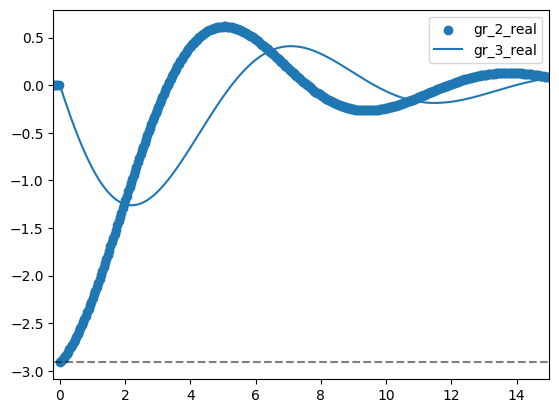

In [ ]:
times = np.linspace(-grid_parameters['time_duration'], grid_parameters['time_duration'], grid_parameters['time_sampling'])

plt.scatter(times,np.real(greps.trace(2)), label = 'gr_2_real')
plt.plot(times,np.real(greps.trace(3)), label = 'gr_3_real')
plt.hlines(-gap_history[-1] * 2,-grid_parameters['time_duration'],grid_parameters['time_duration'], 'k', 'dashed',alpha = 0.5)
plt.xlim(-0.2,15)
#plt.ylim(-3,-2.5)
plt.legend()
plt.show()

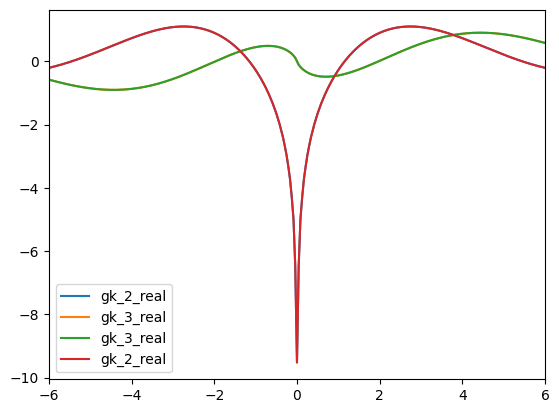

In [ ]:
times = np.linspace(-grid_parameters['time_duration'], grid_parameters['time_duration'], grid_parameters['time_sampling'])

plt.plot(times,np.imag(gkeps.trace(2)), label = 'gk_2_real')
plt.plot(times,np.imag(gkeps.trace(3)), label = 'gk_3_real')
plt.plot(times,np.flip(np.imag((tau_3 * (gkeps.conj().transpose()) * tau_3).trace(3) )), label = 'gk_3_real')
plt.plot(times,np.flip(np.imag((tau_3 * (gkeps.conj().transpose()) * tau_3).trace(2) )), label = 'gk_2_real')

#plt.hlines(-gap_history[-1] * 2,-grid_parameters['time_duration'],grid_parameters['time_duration'], 'k', 'dashed',alpha = 0.5)
plt.xlim(-6,6)
#plt.ylim(-3,-2.5)
plt.legend()
plt.show()

(2, 2, 1501)


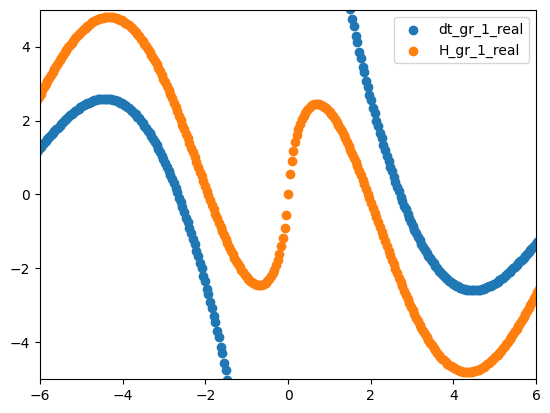

In [ ]:
gap = gap_history[-1]
eta = system_parameters['eta']
tau_0 = NambuKeldyshTensor(1.0, pauli_channel=0)
tau_1 = NambuKeldyshTensor(1.0, pauli_channel=1)
tau_2 = NambuKeldyshTensor(1.0, pauli_channel=2)
tau_3 = NambuKeldyshTensor(1.0, pauli_channel=3)
delta_t = grid_parameters['time_duration'] / grid_parameters['time_sampling']


print(greps.data.shape)

derivative = 1j *(tau_3 * gkeps.gradient(axis = 0) - gkeps.gradient(axis = 0) * tau_3)/delta_t
hamiltonian = -1j * gap *( tau_2 * gkeps - gkeps * tau_2)+1j * eta * ( tau_3 * gkeps + gkeps * tau_3)
times = np.linspace(-grid_parameters['time_duration'], grid_parameters['time_duration'], grid_parameters['time_sampling'] )
tau_grid = times[times <= 0]
temperature = 0.3

#? expand the thermal distribution to be a proper tensor in 2D such that we can do convolution appropriately -- surprisingly unimportant for us in evolution dynamics
#? Add convolution with f to 'correct' the derivative -- figure out how the convolution is done  -- resolve factors of 2 and factors of dt
#? Analytic proof that convolution is the solution of the equations 
#? -- then just look at the last row because it gives t-t' in the easiest way from 0 to -infty and plot it? 

#? check the normalization condition for gk (maybe even gr) -- it could be that 'equilibrium' we generate is not correct 
#? code in the new diagonal entry for gk to see how it compares with gap prediction 
#? Use it to benchmark the other code, to see if its numerical error propagating or the error in expressions that we are using



plt.scatter(times,np.imag(derivative.trace(1)), label = 'dt_gr_1_real')
plt.scatter(times,-np.imag(hamiltonian.trace(1)), label = 'H_gr_1_real')

plt.xlim(-6,6)
plt.ylim(-5,5)
plt.legend()
plt.show()



In [ ]:
gap = gap_history[-1]
eta = system_parameters['eta']
tau_0 = NambuKeldyshTensor(1.0, pauli_channel=0)
tau_1 = NambuKeldyshTensor(1.0, pauli_channel=1)
tau_2 = NambuKeldyshTensor(1.0, pauli_channel=2)
tau_3 = NambuKeldyshTensor(1.0, pauli_channel=3)
delta_t = grid_parameters['time_duration'] / grid_parameters['time_sampling']
print(greps.data.shape)
hamiltonian = -1j * gap *( tau_2 * greps - greps * tau_2)+1j * eta * ( tau_3 * greps - greps * tau_3)
derivative = 1j *(tau_3 * greps.gradient(axis = 0) - greps.gradient(axis = 0) * tau_3)/delta_t

unitary_evolve = ((np.cos(gap * delta_t) * np.exp(-eta * delta_t)) * tau_0 - 1j * np.sin(gap * delta_t) * tau_1 * np.exp(-eta * delta_t)) 
unitary_evolve_inv = ((np.cos(gap * delta_t) * np.exp(-eta * delta_t)) * tau_0 + 1j * np.sin(gap * delta_t) * tau_1 * np.exp(-eta * delta_t)) 

grprime_unitary = ((unitary_evolve * greps.shift(1)) - greps.shift(1) )#+ greps
grprime_unitary_left = ((greps.shift(1) * unitary_evolve_inv)) - greps.shift(1) #+ greps
grprime_linear = greps.gradient(axis = 0)/delta_t #+ greps

#grprime_tot = (grprime_unitary + grprime_unitary_left)/2
derivative_unitary = 1j *(tau_3 *(grprime_unitary) - (grprime_unitary_left) * tau_3)/delta_t
print('delta t is', delta_t)

times = np.linspace(-grid_parameters['time_duration'], grid_parameters['time_duration'], grid_parameters['time_sampling'])

print(np.cosh(gap * delta_t))
print(np.sinh(gap * delta_t))
print(gap * delta_t)

(2, 2, 1501)
delta t is 0.020929997692137197
(1.001125195202922+0j)
(0.04745162241788019+0j)
(0.047433832978287876+0j)


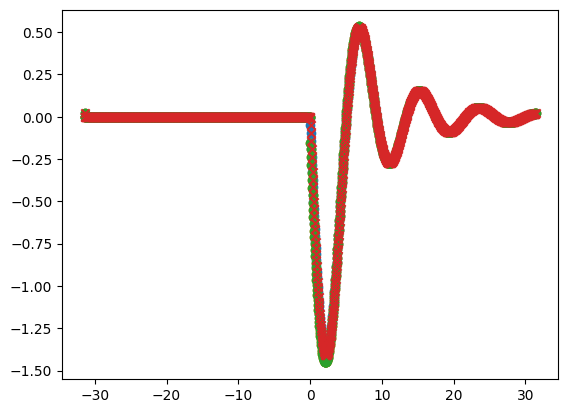

In [ ]:
unitary_evolution_primitive = ((np.cos(gap * delta_t) * np.exp(-eta * delta_t)) * tau_0 - 1j * np.sin(gap * delta_t) * tau_1 * np.exp(-eta * delta_t)) 
unitary_evolution_primitive_inv = ((np.cos(gap * delta_t) * np.exp(-eta * delta_t)) * tau_0 + 1j * np.sin(gap * delta_t) * tau_1 * np.exp(-eta * delta_t))

#gr_new_unitary = ((unitary_evolution_primitive * greps.shift(1))).shift(-1) - greps.shift(-1)  #+ greps
gr_new_unitary = ((unitary_evolution_primitive * greps.shift(1))) #- greps.shift(1)  #+ greps
gr_new_unitary_right = ((greps.shift(1) * unitary_evolution_primitive_inv)) #- greps.shift(1)
#gr_new_unitary_left = 
gr_new_linear = greps.gradient(axis = 0) + greps.shift(1)
#gr_exact = greps

plt.scatter(times,np.real(gr_new_linear.trace(3)))
plt.scatter(times,np.real(gr_new_unitary.trace(3)))
plt.scatter(times,np.real(gr_new_unitary_right.trace(3)))
plt.scatter(times, np.real(greps.shift(1).trace(3)), marker = 'x')
#plt.scatter(times, np.real((gr_new_unitary + gr_new_unitary_right).trace(3))/2)
#plt.xlim(2.1,2.3)
#plt.ylim(-0.45,-0.42)
plt.show()

### Testing state update

State loaded from: /home/filip/Documents/Research/Superconducting_vortices/Keldysh-non-eq/psBQP-keldysh/initial_state_test.pkl
  g^R shape: (2, 2, 2001, 2001)
  g^K shape: (2, 2, 2001, 2001)
  Gap at final time: 1.5230-0.0000j


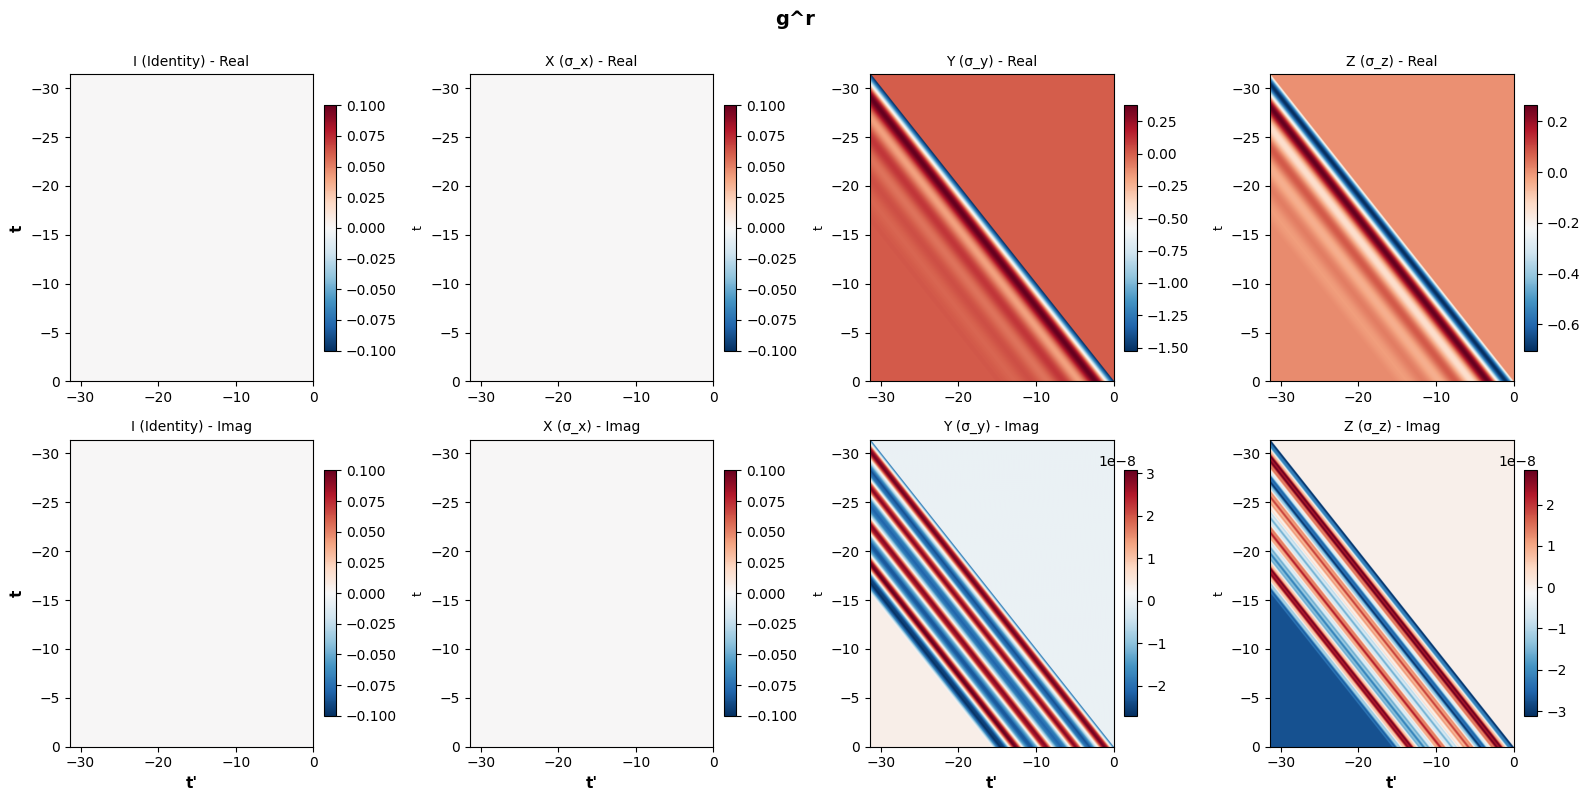

(2, 2, 1, 2001)


KeyboardInterrupt: 

In [ ]:
initial_state = load_state('initial_state_test.pkl')

plot_nambu_components(initial_state.gr, evolution.time_grid, 'g^r')


last_gr_row = initial_state.gr[-2:-1]
print(last_gr_row.data.shape)
#for i in range(300):
#    initial_state.gr.update_entries(last_gr_row * 1000, last_gr_row.complete_transpose() * 0, last_gr_row[:,-2:-1])

plot_nambu_components(initial_state.gr, evolution.time_grid, 'g^r')


## Testing Real-time evolution starting from equilibrium and staying in equilibrium (A = 0)

In [ ]:
# Define grid parameters
grid_parameters = {
    'time_sampling': 1501,
    'time_duration': 2* np.pi * 5,
    'eta': 0.2
}

# Define system parameters
system_parameters = {
    'critical_temperature': 1.0,
    'temperature': 0.3,
    'eta': 0.2

}
# Create evolution object
evolution = UsadelKeldyshEvolution(grid_parameters, system_parameters)
evolution.get_thermal_occupation(temperature=system_parameters['temperature'])
thermal_dist = evolution.thermal_dist
tau_3 = NambuKeldyshTensor(1.0, pauli_channel=3)
print(evolution.time_grid[1]-evolution.time_grid[0])

print(evolution.energy_cutoff)
print(evolution._get_BCS_coupling())
print((1 + evolution._get_BCS_coupling()/2/np.pi * np.log(1/0.3)))

0.02094395102393065
149.90006662225184
1.223456479037451
1.2344365566226891


In [ ]:
initial_state = load_state('initial_state_test.pkl')
#initial_state.gk = initial_state.gk - 2 * tau_3 * thermal_dist
state_1 = load_state('simulated_state.pkl')

State loaded from: /home/filip/Documents/Research/Superconducting_vortices/Keldysh-non-eq/psBQP-keldysh/initial_state_test.pkl
  g^R shape: (2, 2, 1501, 1501)
  g^K shape: (2, 2, 1501, 1501)
  Gap at final time: 1.4563-0.0000j
State loaded from: /home/filip/Documents/Research/Superconducting_vortices/Keldysh-non-eq/psBQP-keldysh/simulated_state.pkl
  g^R shape: (2, 2, 1501, 1501)
  g^K shape: (2, 2, 1501, 1501)
  Gap at final time: 1.4563-0.0000j


(-3.0, 3.0)

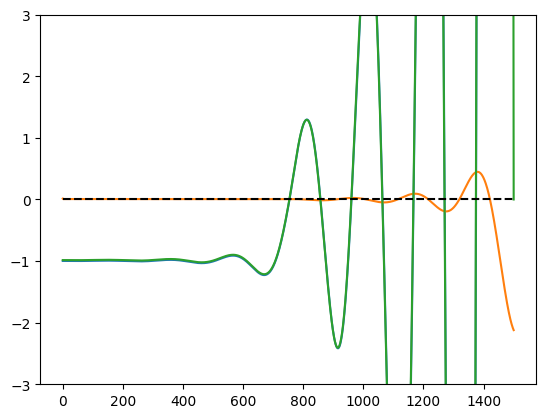

In [ ]:
gr_row = initial_state.gr[-1:,:]
conv = (gr_row @ initial_state.gr)
plt.plot(np.real(conv.trace(0)[0,:]))
plt.plot(np.real((- 1/2 * gr_row[-1:,-1] * initial_state.gr[-1:,:] - 1/2 * gr_row[-1:,0] * initial_state.gr[0:1,:]).trace(0))[0])
plt.plot(np.real(conv.trace(0)[0,:]) + 1 * np.real((- 1/2 * gr_row[-1:,-1] * initial_state.gr[-1:,:] - 1/2 * gr_row[-1:,0:] * initial_state.gr.diagonal_time()).trace(0))[0])
plt.hlines(0,0,1500, linestyles= 'dashed', color = 'black')
plt.ylim(-3,3)

#* the gk integral goes from -infty to t and t'. if t' = -infty the precise convolution with ga should give **exactly** zero -- integral is empty
#* potential issue could be coming from F shift factors? --> are they correctly defined up to +-1? 
#* we are approximating an intergal using midpoint rule, this pattern keeps repeating, the integral with f could be problematic
#* (in code also the index of f, F in precise convolution could also be off)


### Testing gr

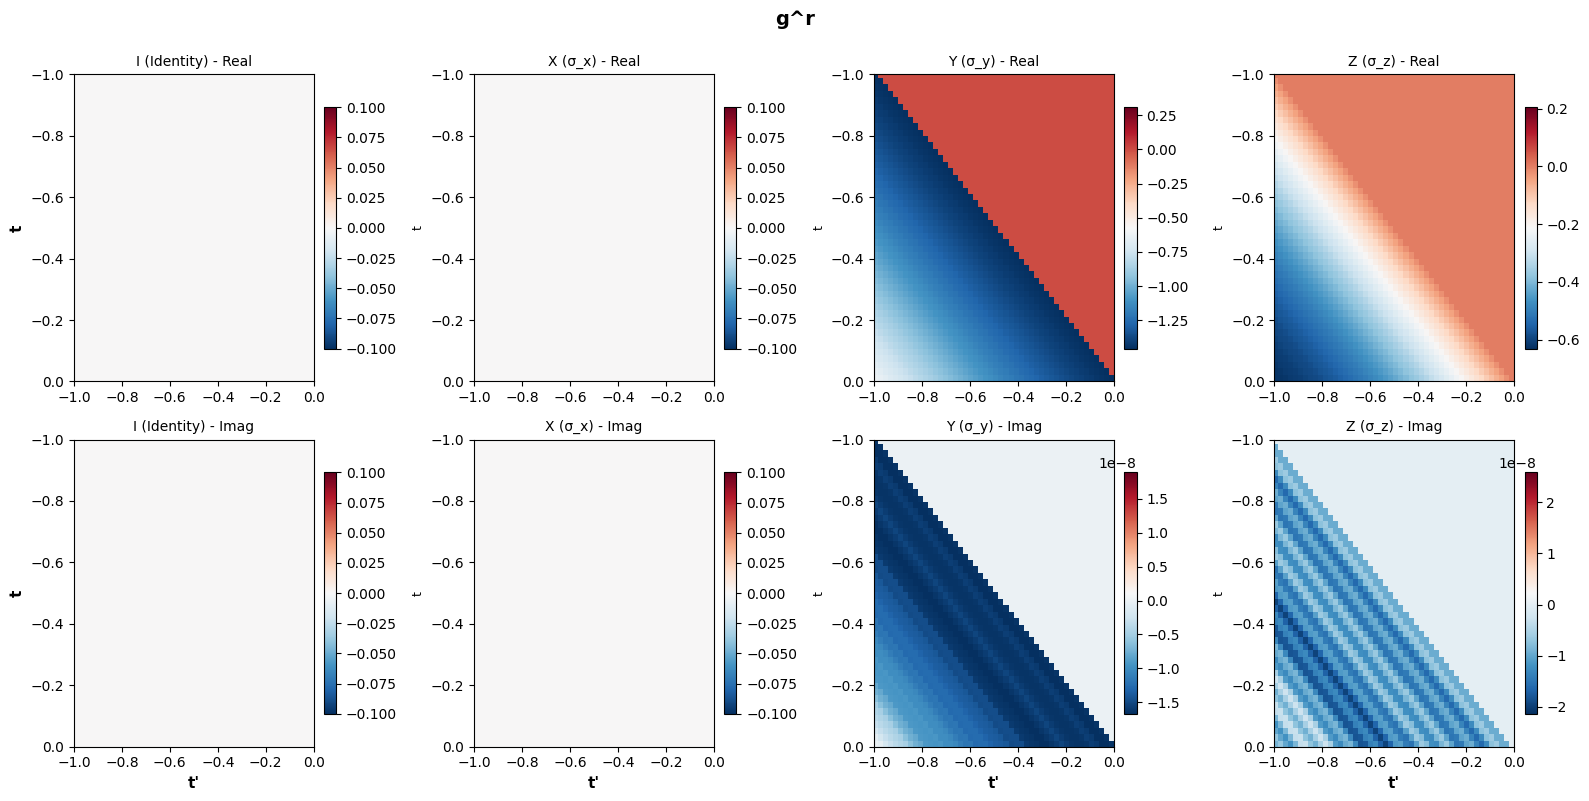

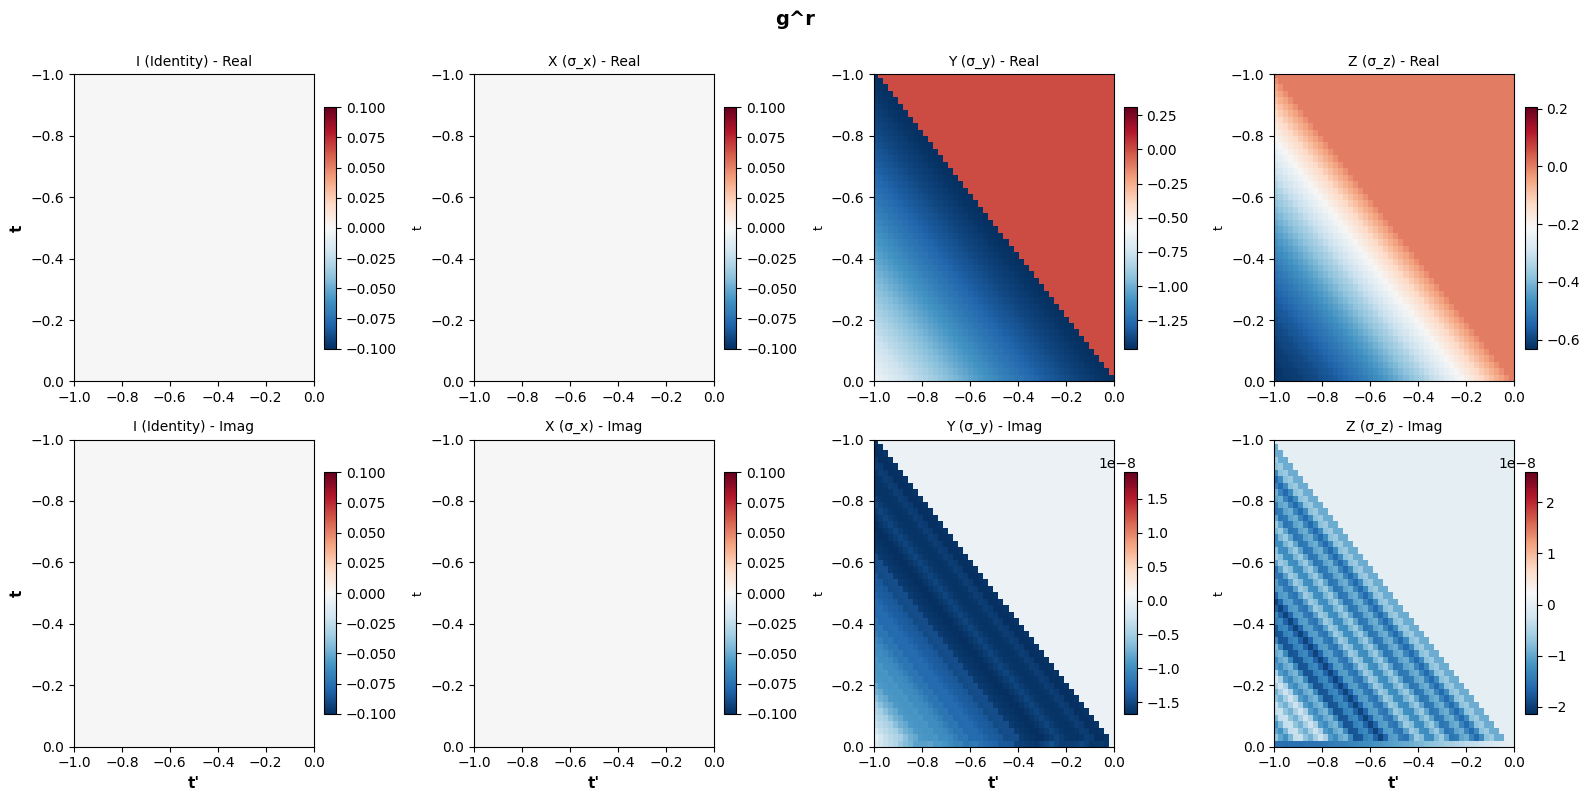

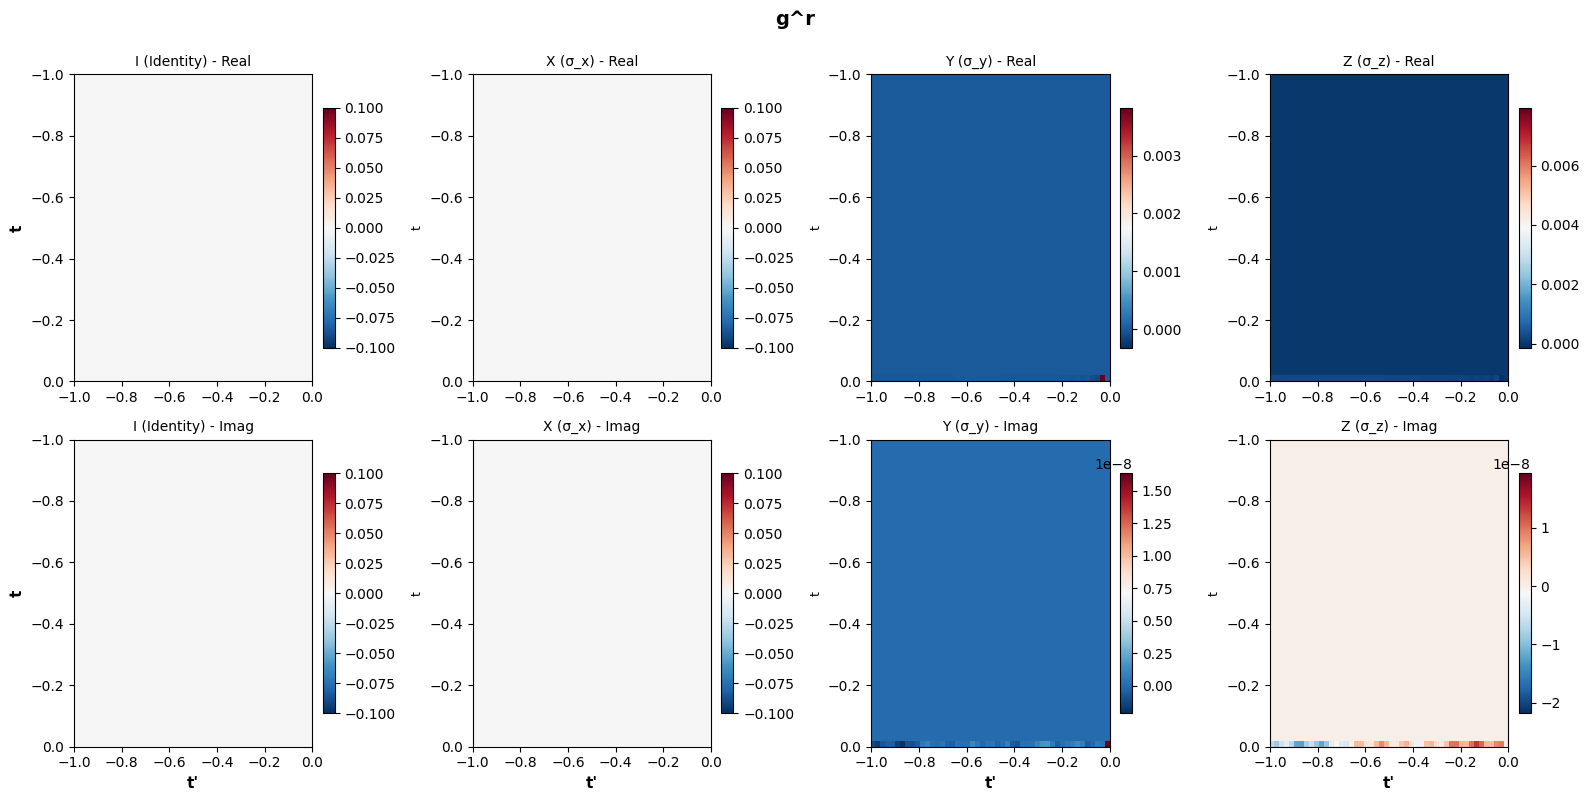

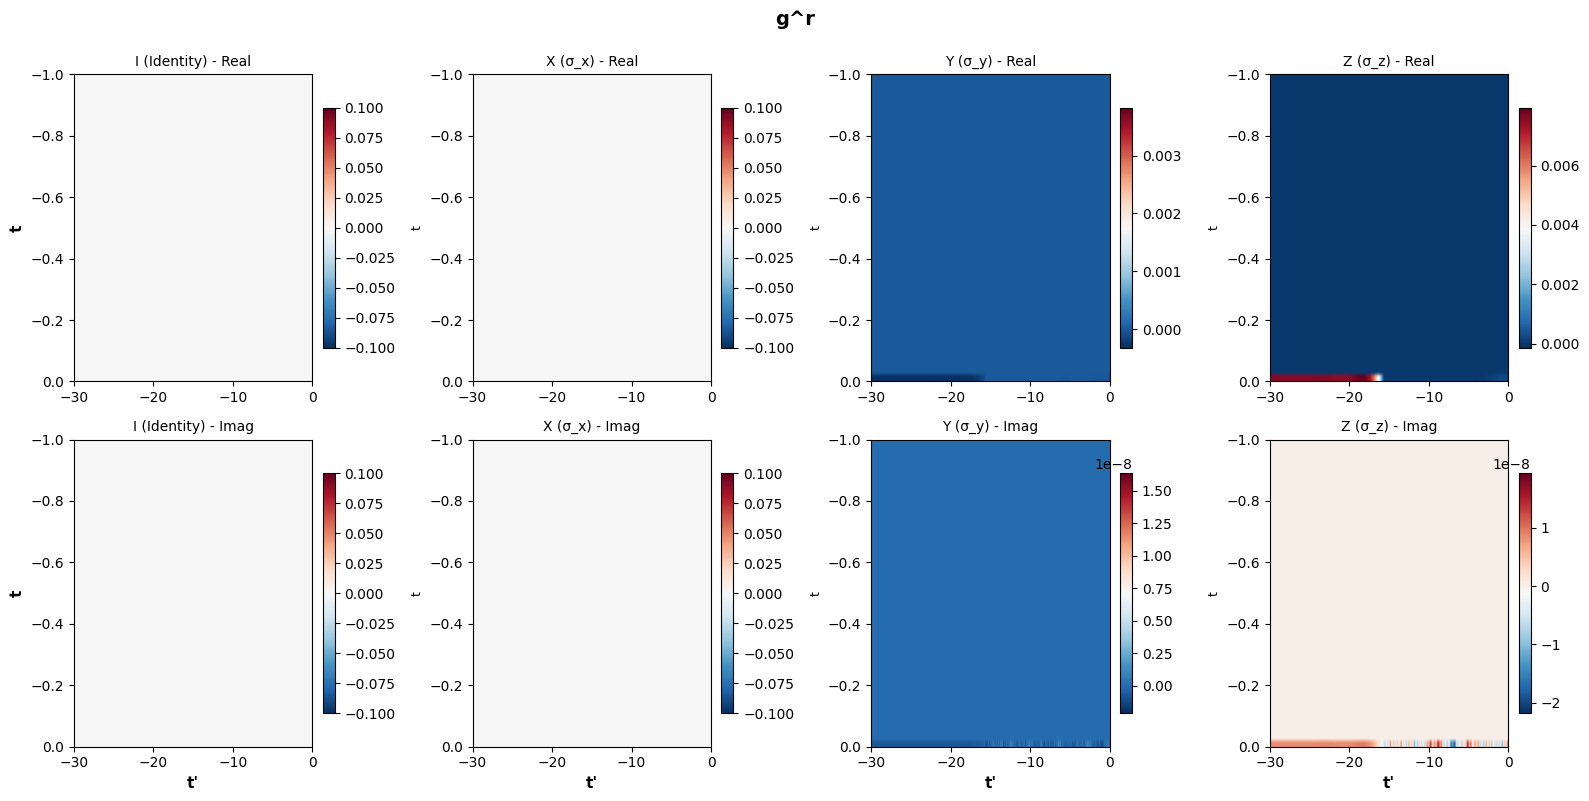

In [ ]:
plot_nambu_components(initial_state.gr, evolution.time_grid, 'g^r', t_lim= (-1,0), tprime_lim=(-1,0))

plot_nambu_components(state_1.gr, evolution.time_grid, 'g^r', t_lim= (-1,0), tprime_lim=(-1,0))#, t_lim= (-4,0), tprime_lim=(-4,0))
plot_nambu_components(state_1.gr - initial_state.gr, evolution.time_grid, 'g^r', t_lim= (-1,0), tprime_lim=(-1,0))#, t_lim= (-4,0), tprime_lim=(-4,0)

plot_nambu_components(state_1.gr - initial_state.gr, evolution.time_grid, 'g^r', t_lim= (-30,0), tprime_lim=(-1,0))#, t_lim= (-4,0), tprime_lim=(-4,0)


### Testing gk

-4.761341571807861j
-4.761341571807861j


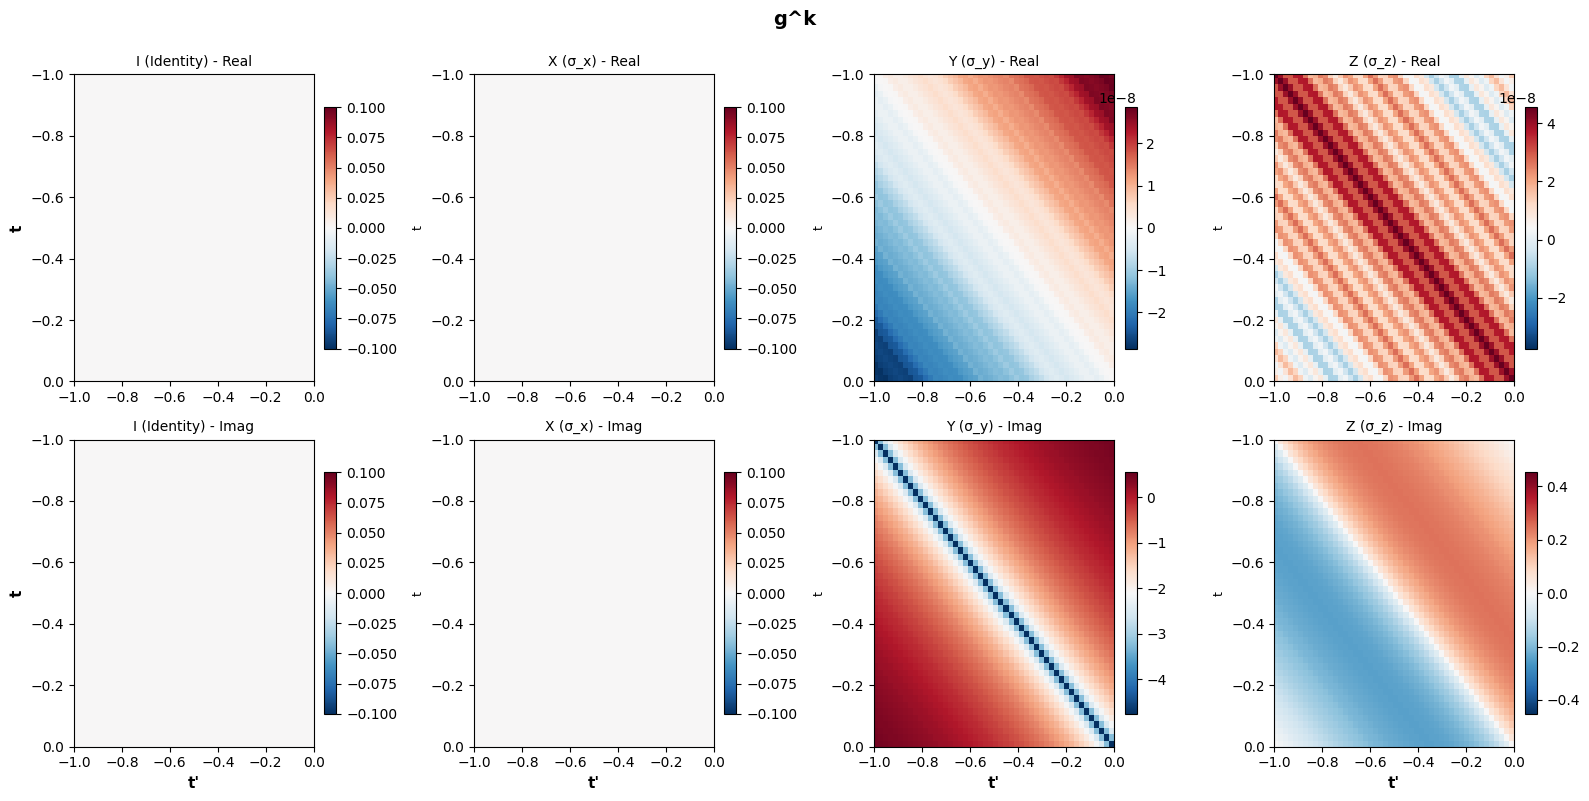

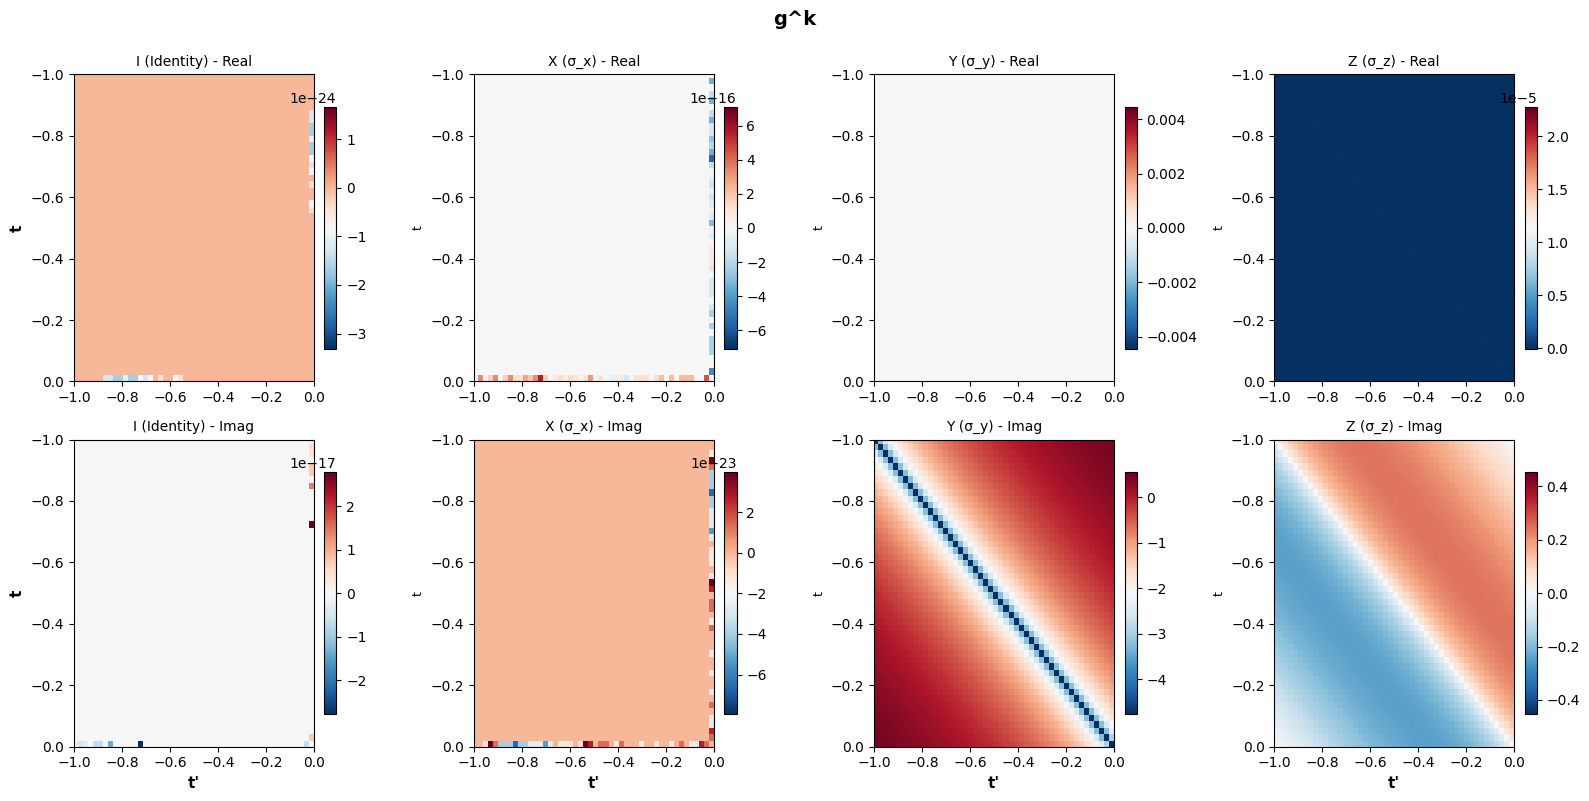

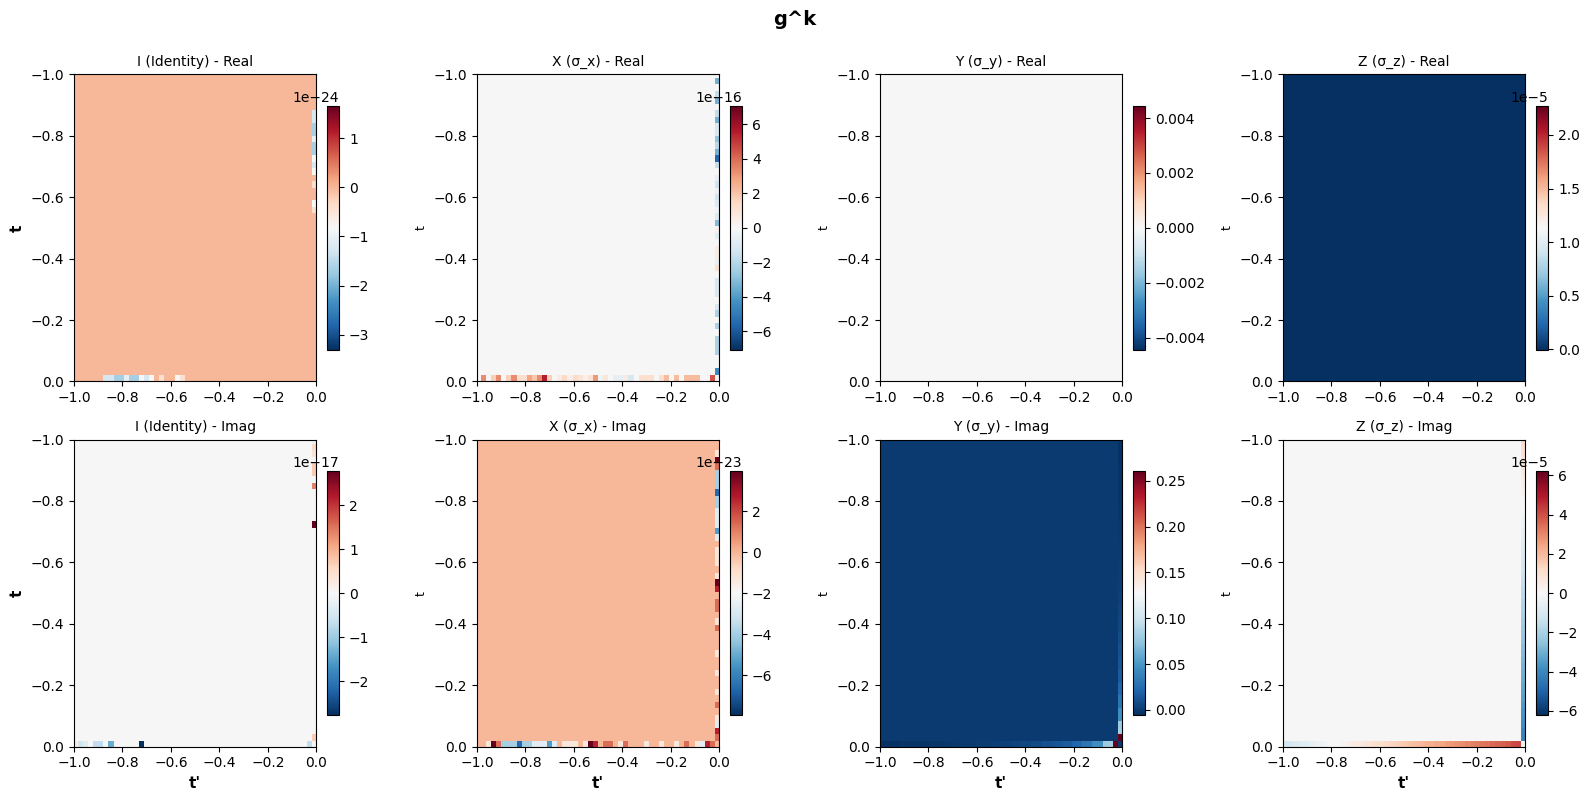

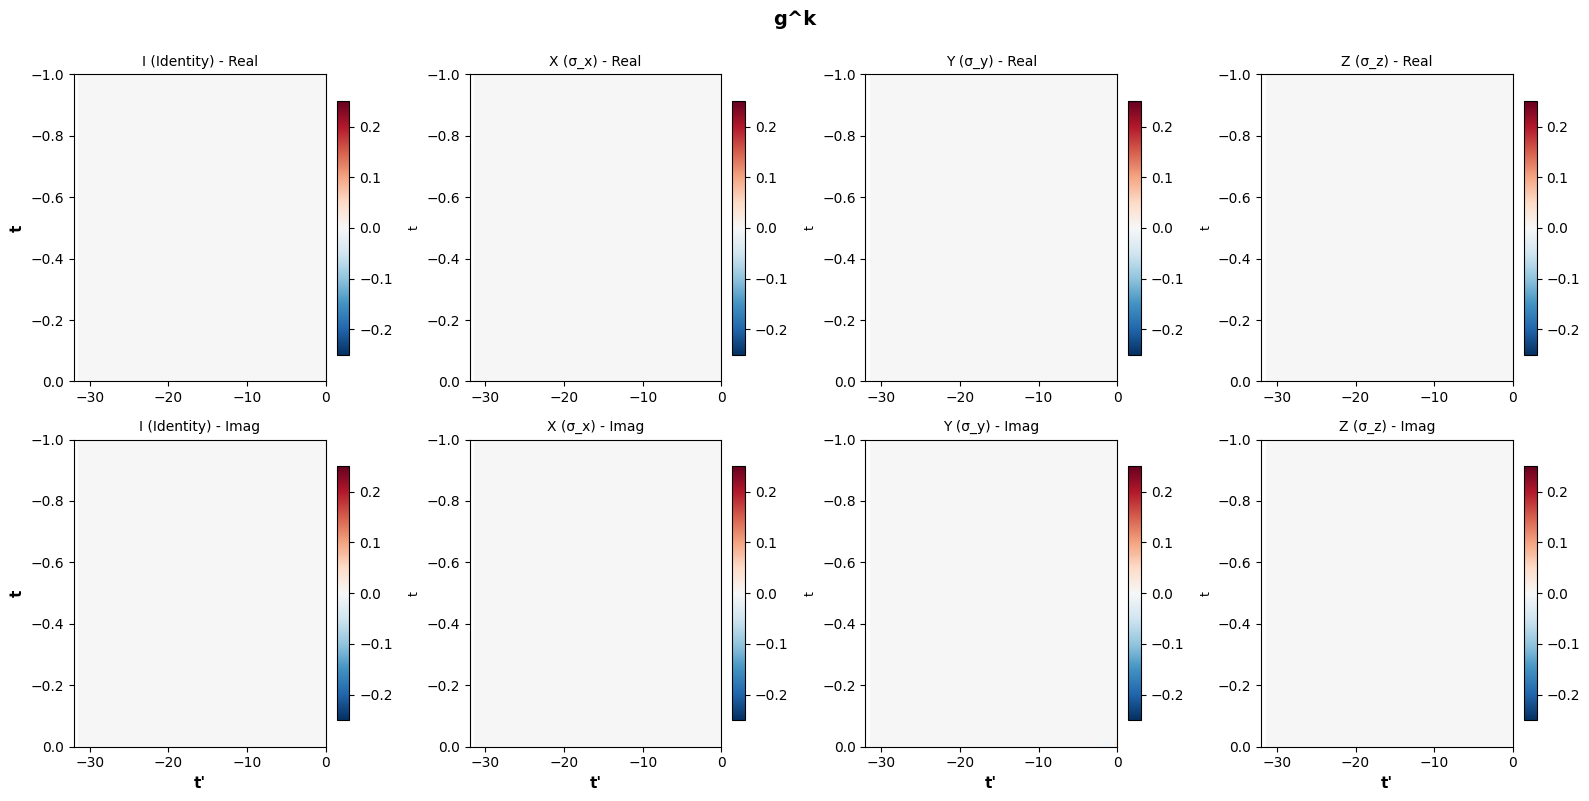

In [ ]:
print(initial_state.gk.trace(2)[-1,-1]/2)
print(state_1.gk.trace(2)[-1,-1]/2)
#plot_nambu_components(initial_state.gk, evolution.time_grid, 'g^k')#, tprime_lim= (-1,0), t_lim= (-1,0))
plot_nambu_components(initial_state.gk, evolution.time_grid, 'g^k', tprime_lim= (-1,0), t_lim= (-1,0))

plot_nambu_components(state_1.gk, evolution.time_grid, 'g^k', tprime_lim= (-1,0), t_lim= (-1,0))#, t_lim= (-4,0), tprime_lim=(-4,0))
#plot_nambu_components(state_2.gk, evolution.time_grid, 'g^k')#, t_lim= (-4,0), tprime_lim=(-4,0))
plot_nambu_components(state_1.gk - initial_state.gk, evolution.time_grid, 'g^k', t_lim= (-1,0),tprime_lim=(-1,0))#, , vmin=-0.005, vmax=0.005)
#plot_nambu_components(state_2.gk - state_1.gk, evolution.time_grid, 'g^k')#, t_lim= (-4,0), tprime_lim=(-4,0)

plot_nambu_components(state_1.gk - initial_state.gk, evolution.time_grid, 'g^k', t_lim= (-32,0), tprime_lim=(-1,0), vmin=-0.25, vmax=0.25)

In [ ]:
plot_nambu_components(initial_state.gk - tau3 * initial_state.gk.complete_transpose() * tau3, evolution.time_grid, 'g^k', t_lim= (-0.5,0), tprime_lim=(-0.5,0))
tau3 = NambuKeldyshTensor(1.0, pauli_channel=3)
#plot_nambu_components(, evolution.time_grid, 'g^k')


#plot_nambu_components(state.gk, evolution.time_grid, 'g^k')

#plot_nambu_components(state.gk - initial_state.gk, evolution.time_grid, 'g^k') 

In [ ]:
a = np.array([1,2,3])
print(a[-2:-1])
print(a[-1:None])

[2]
[3]
